In [29]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import pyarrow.dataset as ds
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_parquet(r"E:\VEDAGYA\Thermal Trace\backend\data\processed\firms_india", engine="pyarrow")

In [5]:
df.shape

(5706071, 18)

In [6]:
df.dtypes

source                            object
product                           object
satellite                         object
instrument                        object
latitude                         float64
longitude                        float64
acq_date                          object
acq_time                          object
observed_at          datetime64[us, UTC]
bright_ti4                       float64
bright_ti5                       float64
frp                              float64
daynight                          object
scan                             float64
track                            float64
source_confidence                 object
version                           object
year                            category
dtype: object

In [7]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5706071 entries, 0 to 5706070
Data columns (total 18 columns):
 #   Column             Dtype              
---  ------             -----              
 0   source             object             
 1   product            object             
 2   satellite          object             
 3   instrument         object             
 4   latitude           float64            
 5   longitude          float64            
 6   acq_date           object             
 7   acq_time           object             
 8   observed_at        datetime64[us, UTC]
 9   bright_ti4         float64            
 10  bright_ti5         float64            
 11  frp                float64            
 12  daynight           object             
 13  scan               float64            
 14  track              float64            
 15  source_confidence  object             
 16  version            object             
 17  year               category           
dtypes:

In [8]:
df['satellite'].value_counts()

satellite
NOAA-20      2944448
Suomi-NPP    2761623
Name: count, dtype: int64

In [10]:
df['instrument'].value_counts()

instrument
VIIRS    5706071
Name: count, dtype: int64

In [15]:
df.isnull().sum()

source               0
product              0
satellite            0
instrument           0
latitude             0
longitude            0
acq_date             0
acq_time             0
observed_at          0
bright_ti4           0
bright_ti5           0
frp                  0
daynight             0
scan                 0
track                0
source_confidence    0
version              0
year                 0
dtype: int64

In [16]:
df[['acq_date', 'acq_time', 'observed_at']].sample(5)

,acq_date,acq_time,observed_at
2170084,2023-10-31,1944,2023-10-31 19:44:00+00:00
386490,2022-03-28,0728,2022-03-28 07:28:00+00:00
651318,2022-04-23,2009,2022-04-23 20:09:00+00:00
2179184,2023-11-03,0713,2023-11-03 07:13:00+00:00
3993487,2025-03-25,0707,2025-03-25 07:07:00+00:00


In [19]:
df.duplicated().sum()

0

In [20]:
exact_dupes = df.duplicated(keep=False)
df[exact_dupes].shape

(0, 18)

In [22]:
near_dupe_key = df['latitude'].round(3).astype(str) + '_' + df['longitude'].round(3).astype(str) + '_' + df['acq_date'].astype(str)
near_dupe_counts = near_dupe_key.value_counts()
near_dupe_counts.describe()

count    5.629209e+06
mean     1.013654e+00
std      1.173277e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      4.000000e+00
Name: count, dtype: float64

In [24]:
spatial_key = df['latitude'].round(3).astype(str) + '_' + df['longitude'].round(3).astype(str)
spatial_counts = spatial_key.value_counts()
spatial_counts.describe()

count    4.714657e+06
mean     1.210283e+00
std      3.143841e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      2.780000e+02
Name: count, dtype: float64

In [27]:
spatial_counts.quantile([0.9, 0.95, 0.99, 0.999])

0.900     1.0
0.950     2.0
0.990     3.0
0.999    46.0
Name: count, dtype: float64

In [28]:
spatial_counts.quantile([0.5, 0.75, 0.9, 0.95, 0.99, 0.999])

0.500     1.0
0.750     1.0
0.900     1.0
0.950     2.0
0.990     3.0
0.999    46.0
Name: count, dtype: float64

In [35]:
print(df['observed_at'].dt.year.value_counts().sort_index())
print(df['observed_at'].dt.month.value_counts().sort_index())
print(df['observed_at'].dt.dayofweek.value_counts().sort_index())

observed_at
2022    1194822
2023    1162529
2024    1126511
2025    1297809
2026     924400
Name: count, dtype: int64
observed_at
1      349259
2      575587
3     1480427
4     1467752
5      617655
6      126072
7       19534
8       19273
9       31839
10     183029
11     478255
12     357389
Name: count, dtype: int64
observed_at
0    814664
1    836369
2    816490
3    812829
4    792919
5    832572
6    800228
Name: count, dtype: int64


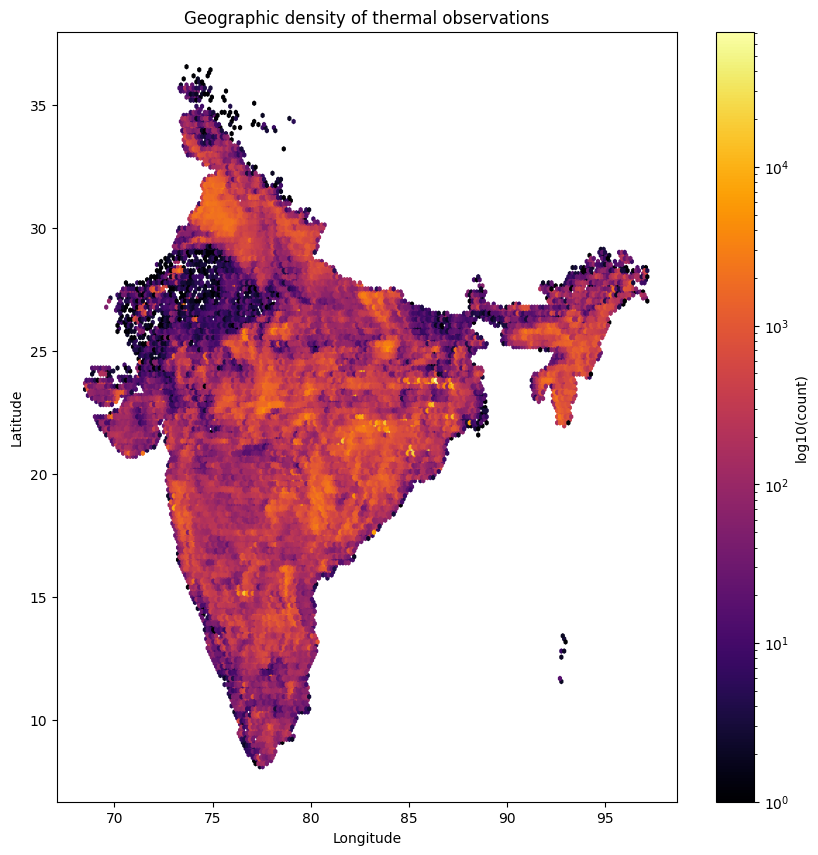

In [39]:
plt.figure(figsize=(10,10))
plt.hexbin(df['longitude'], df['latitude'], gridsize=200, cmap='inferno', bins='log')
plt.colorbar(label='log10(count)')
plt.title('Geographic density of thermal observations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [40]:
df['frp'].describe()

count    5.706071e+06
mean     6.171305e+00
std      1.382851e+01
min      0.000000e+00
25%      1.920000e+00
50%      3.560000e+00
75%      6.320000e+00
max      2.160960e+03
Name: frp, dtype: float64

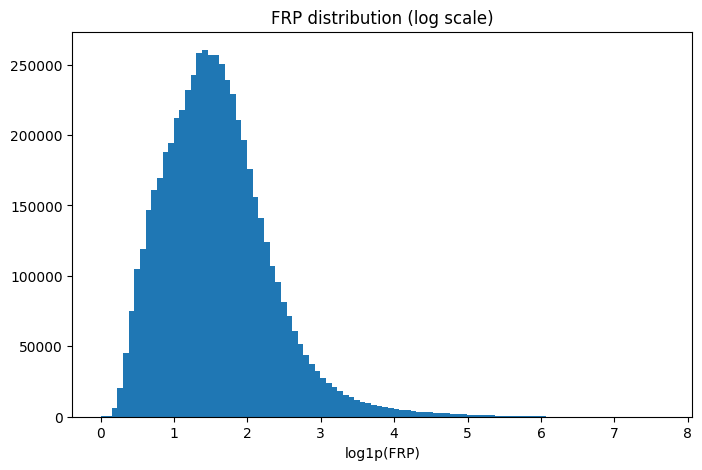

In [44]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df['frp']), bins=100)
plt.xlabel('log1p(FRP)')
plt.title('FRP distribution (log scale)')
plt.show()

In [42]:
df['source_confidence'].value_counts()

source_confidence
n    4517570
l    1037959
h     150542
Name: count, dtype: int64

In [46]:
top_locations = spatial_counts[spatial_counts == spatial_counts.max()].index[:1].tolist() + \
                 spatial_counts.sort_values(ascending=False).index[1:5].tolist()

for loc in top_locations:
    lat, lon = map(float, loc.split('_'))
    mask = (df['latitude'].round(3) == lat) & (df['longitude'].round(3) == lon)
    subset = df[mask].sort_values('observed_at')
    print(f"Location {lat}, {lon} — {len(subset)} observations")
    print(subset[['observed_at', 'frp', 'daynight', 'satellite']].to_string(index=False))
    print("---")

Location 21.921, 83.352 — 278 observations
              observed_at   frp daynight satellite
2022-01-06 20:14:00+00:00  3.61        N   NOAA-20
2022-01-07 08:19:00+00:00  4.43        D Suomi-NPP
2022-01-08 20:29:00+00:00  2.43        N Suomi-NPP
2022-01-16 20:27:00+00:00  1.70        N   NOAA-20
2022-01-17 21:00:00+00:00  2.90        N Suomi-NPP
2022-01-19 07:02:00+00:00  3.53        D   NOAA-20
2022-01-21 19:44:00+00:00  4.63        N Suomi-NPP
2022-01-28 20:02:00+00:00  2.04        N   NOAA-20
2022-01-31 08:17:00+00:00  5.65        D   NOAA-20
2022-02-06 19:44:00+00:00  2.05        N Suomi-NPP
2022-02-07 20:15:00+00:00  2.03        N   NOAA-20
2022-02-13 07:34:00+00:00  4.08        D   NOAA-20
2022-02-18 08:31:00+00:00  8.26        D Suomi-NPP
2022-02-21 20:03:00+00:00  1.68        N Suomi-NPP
2022-02-23 19:25:00+00:00  2.63        N Suomi-NPP
2022-03-01 08:25:00+00:00  3.70        D Suomi-NPP
2022-03-04 07:28:00+00:00  4.32        D Suomi-NPP
2022-03-05 20:28:00+00:00  4.14        